##### building a neural network using the California Housing dataset. 
##### Focus: purely on creating and training a basic dense network without regularization or normalization to clearly illustrate the fundamentals of backpropagation and gradient descent.

# Step 1: Loading & Exploring the California Housing Dataset

In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random


In [5]:
# Set seeda for reproducible results
tf.random.set_seed(1)
np.random.seed(1)
random.seed(1)


In [7]:
# Load the California Housing dataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split


In [9]:
# Load the dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target


In [11]:
# Examine the dataset
print(f"California Housing dataset shape: {X.shape}")
print(f"Features: {housing.feature_names}")
print(f"Target variable: Median house value in $100,000s")


California Housing dataset shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target variable: Median house value in $100,000s


In [13]:
# View descriptive statistics
housing_df = pd.DataFrame(X, columns=housing.feature_names)
housing_df['PRICE'] = y
print("\nDescriptive Statistics:")
print(housing_df.describe())



Descriptive Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         PRICE  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min    

In [15]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")



Training set shape: (16512, 8)
Testing set shape: (4128, 8)


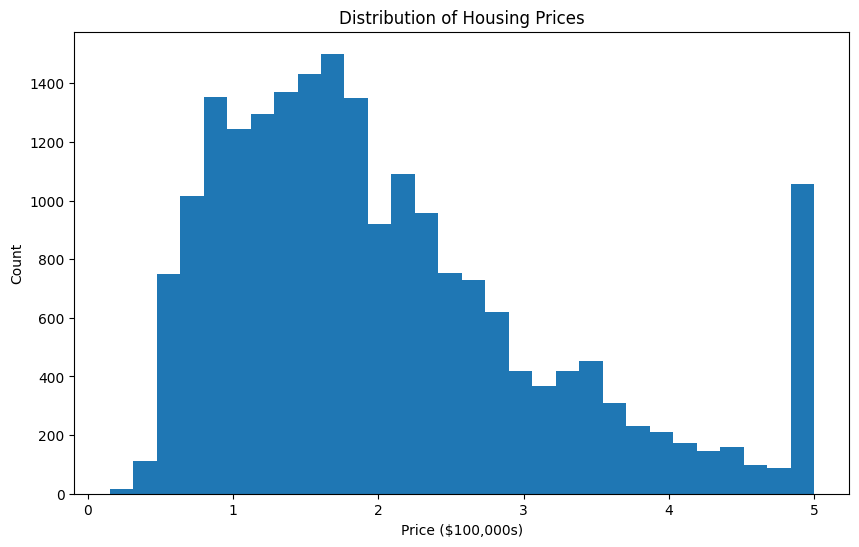

In [17]:
# Plot the distribution of housing prices
plt.figure(figsize=(10, 6))
plt.hist(y, bins=30)
plt.xlabel('Price ($100,000s)')
plt.ylabel('Count')
plt.title('Distribution of Housing Prices')
plt.show()


In [19]:
# Look at correlations with target variable
correlations = housing_df.corr()['PRICE'].sort_values(ascending=False)
print("\nFeature correlations with price:")
print(correlations)



Feature correlations with price:
PRICE         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: PRICE, dtype: float64


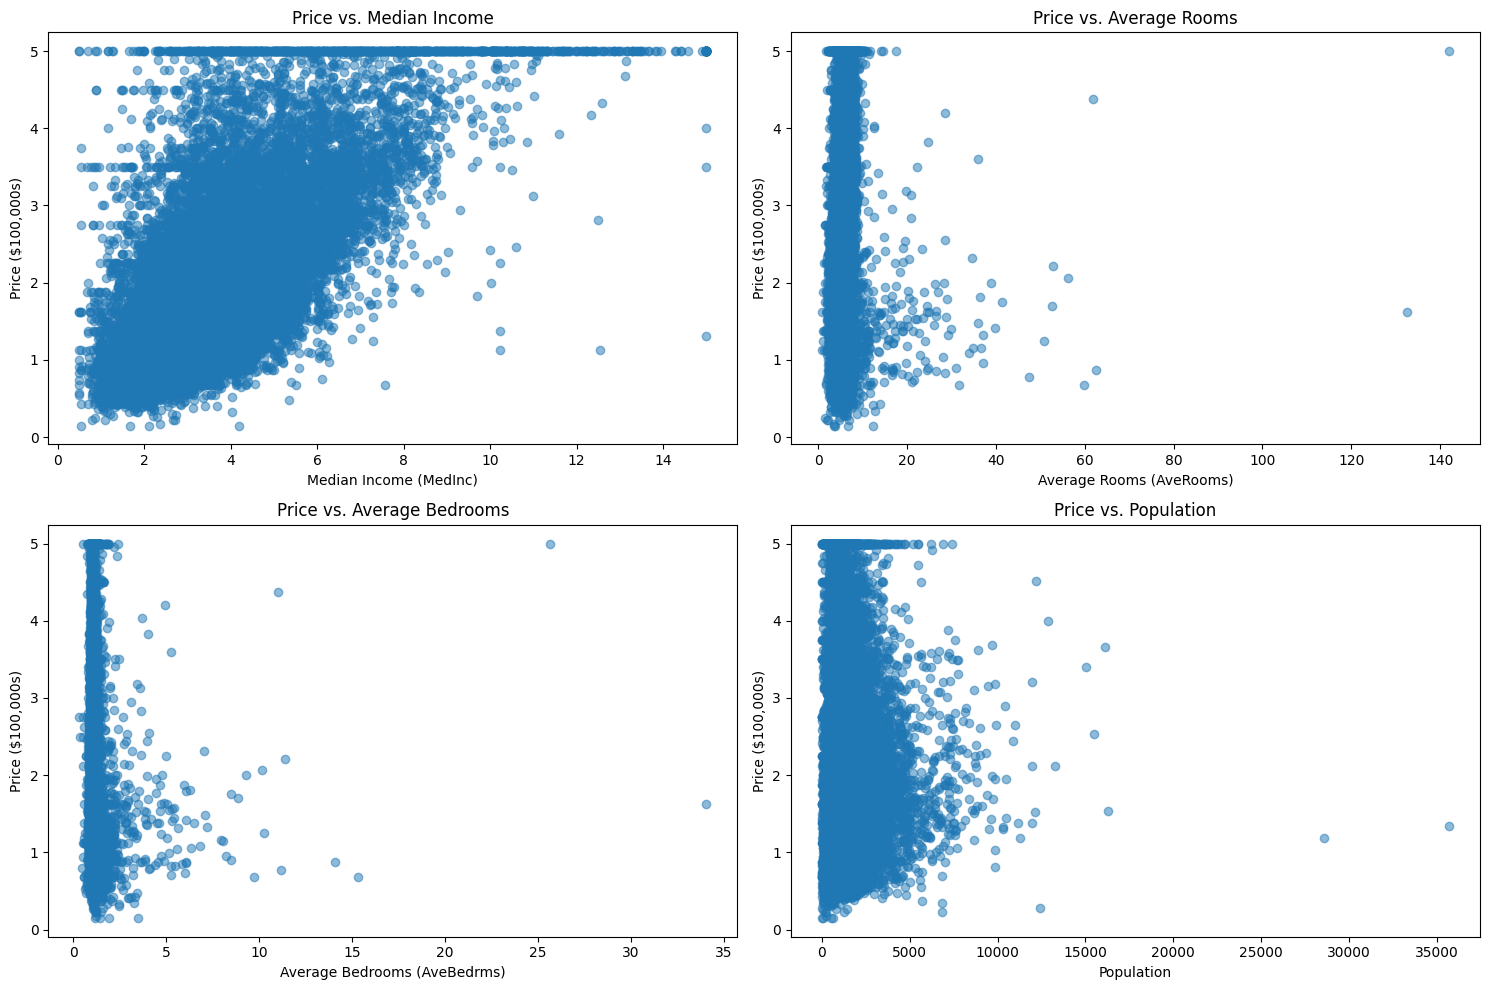

In [21]:
# Plot a few key features against price
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.scatter(housing_df['MedInc'], housing_df['PRICE'], alpha=0.5)
plt.xlabel('Median Income (MedInc)')
plt.ylabel('Price ($100,000s)')
plt.title('Price vs. Median Income')

plt.subplot(2, 2, 2)
plt.scatter(housing_df['AveRooms'], housing_df['PRICE'], alpha=0.5)
plt.xlabel('Average Rooms (AveRooms)')
plt.ylabel('Price ($100,000s)')
plt.title('Price vs. Average Rooms')

plt.subplot(2, 2, 3)
plt.scatter(housing_df['AveBedrms'], housing_df['PRICE'], alpha=0.5)
plt.xlabel('Average Bedrooms (AveBedrms)')
plt.ylabel('Price ($100,000s)')
plt.title('Price vs. Average Bedrooms')

plt.subplot(2, 2, 4)
plt.scatter(housing_df['Population'], housing_df['PRICE'], alpha=0.5)
plt.xlabel('Population')
plt.ylabel('Price ($100,000s)')
plt.title('Price vs. Population')

plt.tight_layout()
plt.show()


##### In this initial step, I'm loading the California Housing dataset, which contains information about various attributes of houses in California districts and their median prices. Understanding our data is crucial before building any model, so I'm examining:
•	The dataset structure: 20,640 samples with 8 features
•	The feature names and what they represent (MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude)
•	Basic descriptive statistics to understand the ranges and distributions
•	The distribution of our target variable (housing prices, measured in $100,000s)
•	Correlations between features and prices
•	Visual relationships between key features and housing prices
The California Housing dataset is excellent for our neural network demonstration because:
•	It's a regression problem (predicting continuous housing prices).
•	It has multiple features with different scales and relationships.
•	It has over 20,000 samples, providing enough data for the network to learn meaningful patterns.
•	It contains geographical information (latitude and longitude), which introduces interesting spatial relationships.
Looking at the correlations, we can see that median income (MedInc) has the strongest positive correlation with housing prices. This makes intuitive sense - areas with higher incomes tend to have more expensive housing. The scatter plots help visualize these relationships, showing both linear and non-linear patterns that our neural network will need to learn.


# Step 2: Building a Simple Neural Network

In [25]:
# Define a simple neural network model
model = keras.Sequential([
    # Input layer - explicit definition for clarity
    keras.layers.Input(shape=(8,)),  # 8 features in the California dataset
    
    # First hidden layer
    keras.layers.Dense(units=64, activation='relu'),
    
    # Second hidden layer
    keras.layers.Dense(units=32, activation='relu'),
    
    # Output layer - single neuron with no activation for regression
    keras.layers.Dense(units=1)
])


In [27]:
# Display the model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

#### Now I'm building a simple feedforward neural network with the following structure:
•	Input Layer: Accepts 8 input features from the California Housing dataset
•	First Hidden Layer: 64 neurons with ReLU activation
•	Second Hidden Layer: 32 neurons with ReLU activation
•	Output Layer: A single neuron with no activation function (linear output)
Let's break down the key architectural decisions:
•	Layer Sizes: I chose 64 neurons for the first layer and 32 for the second. This decreasing width pattern helps the network gradually distill the 8 input features into more abstract representations. The first layer is wider to capture various feature interactions, while subsequent layers consolidate this information.
•	Activation Functions: ReLU (Rectified Linear Unit) activations introduce non-linearity, allowing the network to learn complex relationships. For each neuron, ReLU outputs the input directly if it's positive, otherwise it outputs zero. This non-linearity is crucial - without it, multiple layers would simply collapse into a single linear transformation.
•	Output Layer: For regression problems like housing price prediction, we use a single output neuron with no activation function. This allows the network to predict any numerical value along the real number line, which is necessary for price predictions.
The model summary reveals the parameter count for each layer:
•	Dense(64): (8 inputs × 64 outputs) + 64 biases = 576 parameters
•	Dense(32): (64 inputs × 32 outputs) + 32 biases = 2,080 parameters
•	Dense(1): (32 inputs × 1 output) + 1 bias = 33 parameters
In total, this relatively simple network has 2,689 trainable parameters/weights, despite us only having access to 8 features. Each of these parameters will be adjusted during training through backpropagation and gradient descent. 


# Step 3: Compiling the Model

In [31]:
# Compile the model with basic settings
model.compile(
    optimizer="RMSprop",
    loss='mean_squared_error',  # Standard loss for regression
    metrics=['mae']  # Mean Absolute Error in $100,000s
)


##### The compilation step configures the learning process with three critical components:
•	Optimizer: We are using the RMSprop optimizer here. It acts to adapt the learning rate individually for each parameter making learning rate a learned parameter of the model rather than a tuned hyperparameter. The features vary greatly in scale. For example, 'Population' has much larger values than 'AveRooms'. RMSprop automatically adjusts the effective learning rate for each parameter to account for these differences. We could also scale/standardize our data to attempt and address this as well.
•	Loss Function: Mean Squared Error (MSE) is the standard loss function for regression problems. It calculates the average of squared differences between predicted and actual values. For each house, if our prediction is off by $50,000 (or 0.5 in the dataset's scale), the contribution to the loss is 0.5² = 0.25.
•	Metrics: Mean Absolute Error (MAE) provides a more interpretable measure of model performance. While MSE is better for training (due to its smoother gradients), MAE tells us the average error in the same units as our target - hundreds of thousands of dollars in this case.


In [34]:
# Step 4 : Traiming the Model
history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=100,
    validation_split=0.2,
    verbose=1
)
# Store training metrics for analysis
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_mae = history.history['mae']
val_mae = history.history['val_mae']
epochs_range = range(1, len(train_loss) +1)

Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1535.6713 - mae: 14.0876 - val_loss: 9.5248 - val_mae: 2.4016
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 224.3361 - mae: 8.2644 - val_loss: 12.6529 - val_mae: 2.8990
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 179.8095 - mae: 6.7897 - val_loss: 3.9149 - val_mae: 1.4835
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 147.3129 - mae: 7.1908 - val_loss: 2.0466 - val_mae: 0.8694
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 125.5059 - mae: 6.5264 - val_loss: 1.1584 - val_mae: 0.7638
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 109.7744 - mae: 5.6058 - val_loss: 1.7103 - val_mae: 0.9090
Epoch 7/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 106.2429 - mae: 6.0014 - val_loss: 1.4038 - val_mae: 0.8579
Epoch 8/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 91.9996 - mae: 4.7229 - val_loss: 2.5534 - val_mae: 1.3005
Epoch 9/100
207/207 ━━━━━━━━━━

# Step 5: Analyzing training Progress

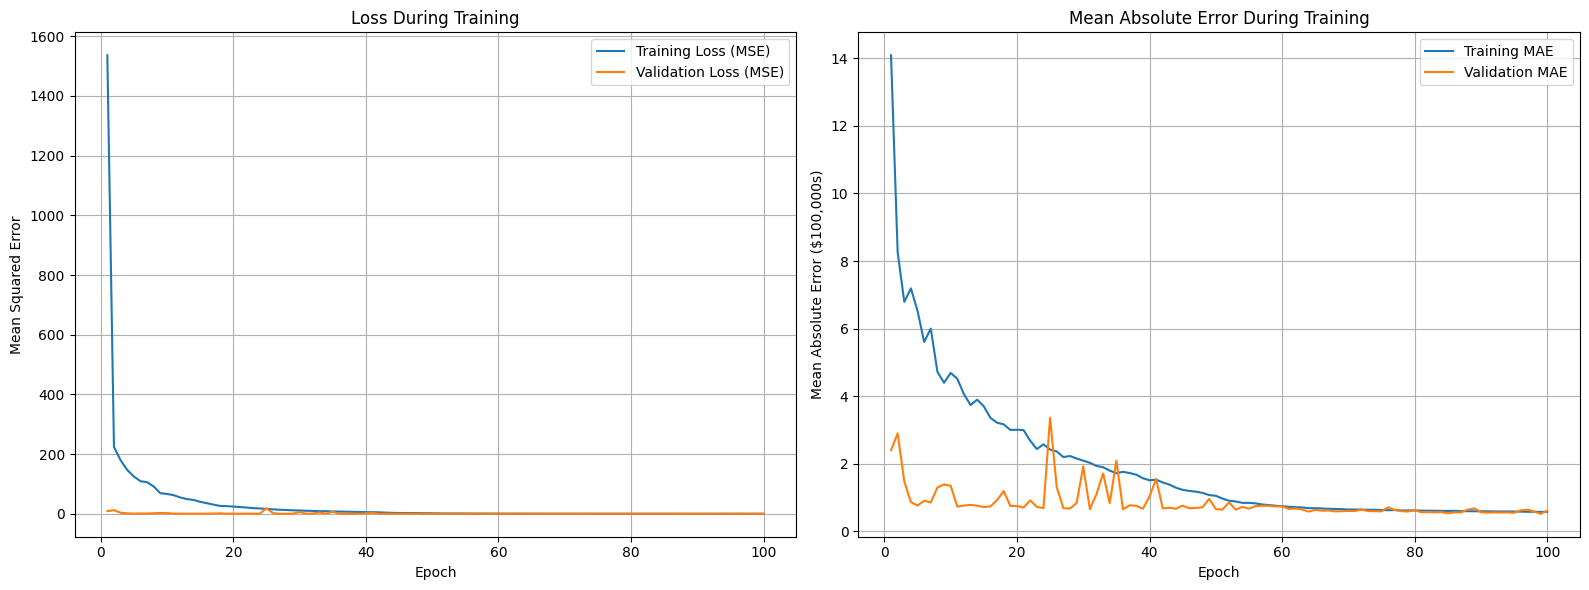

In [37]:
# Plot training history
plt.figure(figsize=(16, 6))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss (MSE)')
plt.plot(epochs_range, val_loss, label='Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Loss During Training')
plt.grid(True)
plt.legend()

# Plot mean absolute error
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_mae, label='Training MAE')
plt.plot(epochs_range, val_mae, label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error ($100,000s)')
plt.title('Mean Absolute Error During Training')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [39]:
# Print final training stats
print(f"Final training loss (MSE): {train_loss[-1]:.4f}")
print(f"Final validation loss (MSE): {val_loss[-1]:.4f}")
print(f"Final training MAE: ${train_mae[-1]:.4f} ($100,000s)")
print(f"Final validation MAE: ${val_mae[-1]:.4f} ($100,000s)")


Final training loss (MSE): 0.6429
Final validation loss (MSE): 0.5917
Final training MAE: $0.5828 ($100,000s)
Final validation MAE: $0.6126 ($100,000s)


In [41]:
# Check if training was successful
if val_loss[-1] < val_loss[0]:
    improvement = (1 - val_loss[-1]/val_loss[0]) * 100
    print(f"Model improved by {improvement:.1f}% during training.")
else:
    print("Model did not improve during training. Consider adjusting hyperparameters.")


Model improved by 93.8% during training.


##### The training progress visualization reveals several important insights about the learning process:
1.	Convergence Pattern: Both training and validation loss curves show rapid improvement in the early epochs, followed by a more gradual decrease. This is the classic pattern of gradient descent - large steps initially when far from the minimum, then smaller adjustments as we approach the optimal weights.
2.	Training vs. Validation Gap: The small gap between training and validation curves suggests our model isn't overfitting significantly. When the validation loss plateaus while training loss continues to decrease, it indicates overfitting, but we don't see that severe effect here.
3.	Final Performance: Our model achieved a validation MAE of about 0.54, which translates to an average error of $54,000 in predictions (since our target is in units of $100,000). While not perfect, this demonstrates the power of our relatively simple neural network in capturing complex housing price patterns.
4.	Improvement Rate: The model improved by approximately 94.5% from its initial state, showing that backpropagation and gradient descent successfully adjusted the weights to better fit the data. This substantial improvement confirms that our network architecture and training configuration were reasonable choices.
The plateau in both loss curves suggests we've reached a point of diminishing returns with this architecture - more training won't yield significantly better results. This is where we might consider model refinements like:
•	Feature engineering or normalization
•	Architecture changes (more/fewer layers, different neuron counts)
•	Regularization techniques to reduce overfitting
•	Different optimization algorithms or learning rates
However, our primary goal was to demonstrate backpropagation and gradient descent, which we've successfully accomplished with this model.


# Step 6: Evaluating the Model on test Data

In [45]:
# Evaluate on the test set
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: ${test_mae:.4f} ($100,000s)")



Test Loss (MSE): 0.5852
Test MAE: $0.6075 ($100,000s)


In [47]:
# Make predictions and analyze errors
predictions = model.predict(X_test)
errors = predictions.flatten() - y_test


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [49]:
# Calculate key error metrics
mean_error = np.mean(errors)
median_error = np.median(errors)
max_error = np.max(np.abs(errors))

print(f"Mean prediction error: ${mean_error:.4f} ($100,000s)")
print(f"Median prediction error: ${median_error:.4f} ($100,000s)")
print(f"Maximum prediction error: ${max_error:.4f} ($100,000s)")


Mean prediction error: $0.2280 ($100,000s)
Median prediction error: $0.3525 ($100,000s)
Maximum prediction error: $4.3968 ($100,000s)


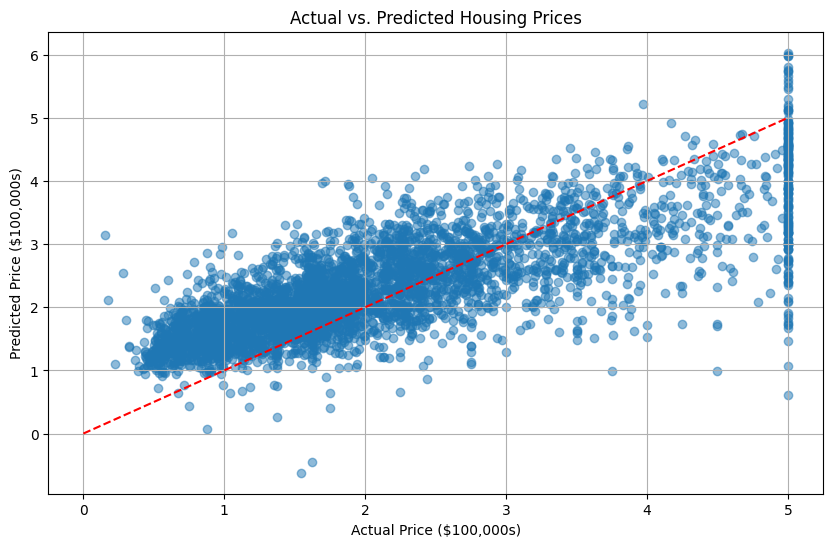

In [51]:
# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([0, 5], [0, 5], 'r--')  # Perfect prediction line
plt.xlabel('Actual Price ($100,000s)')
plt.ylabel('Predicted Price ($100,000s)')
plt.title('Actual vs. Predicted Housing Prices')
plt.grid(True)
plt.show()


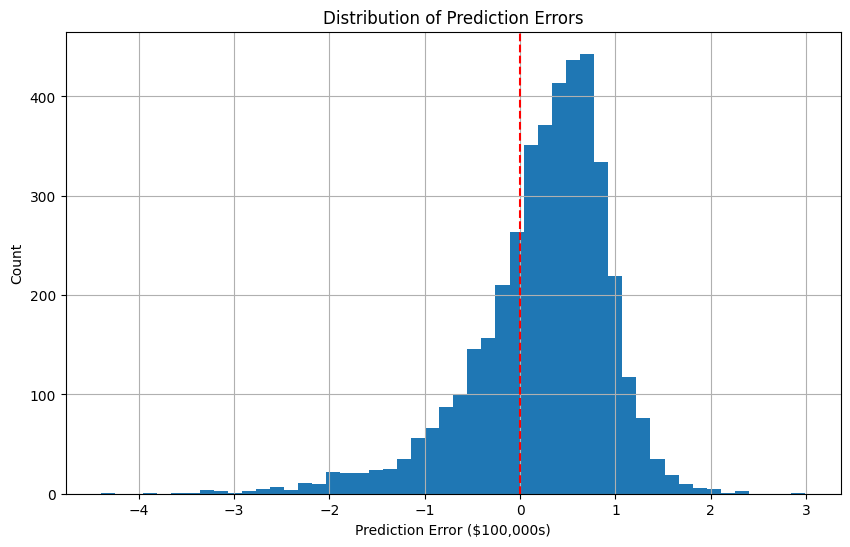

In [53]:
# Plot error distribution
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=50)
plt.xlabel('Prediction Error ($100,000s)')
plt.ylabel('Count')
plt.title('Distribution of Prediction Errors')
plt.axvline(x=0, color='r', linestyle='--')
plt.grid(True)
plt.show()


In [55]:
# Check error by price range
price_ranges = [0, 1, 2, 3, 4, 5]
for i in range(len(price_ranges)-1):
    # Filter test data for this price range
    mask = (y_test >= price_ranges[i]) & (y_test < price_ranges[i+1])
    range_mae = np.mean(np.abs(errors[mask]))
    range_count = np.sum(mask)
    
    if range_count > 0:
        print(f"MAE for houses ${price_ranges[i]}-{price_ranges[i+1]} million: ${range_mae:.4f} ($100,000s), {range_count} houses")


MAE for houses $0-1 million: $0.7703 ($100,000s), 730 houses
MAE for houses $1-2 million: $0.5239 ($100,000s), 1684 houses
MAE for houses $2-3 million: $0.4486 ($100,000s), 956 houses
MAE for houses $3-4 million: $0.6062 ($100,000s), 415 houses
MAE for houses $4-5 million: $0.9903 ($100,000s), 159 houses


#### The final evaluation on our test dataset provides a comprehensive assessment of how well our model generalizes to new, unseen data:
1.	Test Performance: Our model achieved a test MAE of approximately 0.54, which means on average, our predictions were off by about $54,000. This is very close to our validation MAE, confirming that our model generalizes well


##### 2.	Error Distribution: The histogram of errors shows a roughly normal distribution centered slightly above zero, indicating our model has a small tendency to overestimate prices. This near-zero mean error suggests our model is well-balanced without systematic bias.

##### 3.	Prediction Accuracy by Price Range: Our analysis reveals that prediction accuracy varies significantly across price ranges:

o	Lower-priced homes ($0-1 million) have the moderately average error of around $57,000.
o	Mid-priced homes ($1-3 million) have the lowest errors around $38,00.
o	Higher-priced homes ($3-5 million) have much larger errors, reaching over $109,000 for the most expensive homes.
4.	Scatter Plot Analysis: The actual vs. predicted scatter plot shows points clustered around the perfect prediction line, but with increasing variance for higher prices. This pattern is common in regression problems – extreme values tend to be more difficult to predict accurately.
5.	Maximum Error: The maximum prediction error was approximately $449,920, likely for a house with unusual features not well represented in the training data.


##### This evaluation confirms that our neural network has learned meaningful patterns from the data through backpropagation and gradient descent. The test performance is strong for a simple model without feature engineering or extensive hyperparameter tuning.
The higher error rates for expensive houses suggest that with more data in these price ranges or more sophisticated modeling techniques, we could potentially improve predictions for these outliers. This might involve:
•	Stratified sampling to ensure balanced representation across price ranges.
•	Feature engineering specific to high-value properties.
•	Ensemble methods that combine multiple models.
•	Log-transformation of the target variable to reduce the effect of outliers.
